## 🧠💡 Intelligent Systems  for Smart Health 👨‍⚕👩‍⚕️🔬🌡️

# Portfolio Exercise 2 - Ocular Disease Recognition
## CNN (Convolutional Neural Networks)

Convolutional Neural Networks, or CNNs for short, are a powerful type of neural network commonly used in computer vision tasks. They are particularly well-suited to tasks like image classification and object detection because they are able to automatically learn and extract relevant features from input images. CNNs consist of multiple layers, each of which performs a different type of processing on the input data. These layers typically include convolutional layers, which extract features from the input images, and pooling layers, which downsample the output of the convolutional layers. By stacking these layers on top of one another, a CNN is able to learn increasingly complex representations of the input data.

In [84]:
# Imports necessary for data handling/import/exploration
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import torch_directml
from sklearn.metrics import roc_curve, auc, classification_report, confusion_matrix

import warnings

from torchinfo import summary
from tqdm import tqdm


# Suppress FutureWarning messages
warnings.simplefilter(action='ignore', category=FutureWarning)

In [85]:
# Imports necessary for deep learning model
import torch.nn as nn
from torchvision import models, transforms
import torch.nn.functional as F

## Dataset



Ocular Disease Intelligent Recognition (ODIR) is a structured ophthalmic database of 5,000 patients with age, color fundus photographs from left and right eyes and doctors' diagnostic keywords from doctors.

This dataset is meant to represent ‘‘real-life’’ set of patient information collected by Shanggong Medical Technology Co., Ltd. from different hospitals/medical centers in China. In these institutions, fundus images are captured by various cameras in the market, such as Canon, Zeiss and Kowa, resulting into varied image resolutions.

Annotations were labeled by trained human readers with quality control management. They classify patient into eight labels including:

* Normal (N),
* Diabetes (D),
* Glaucoma (G),
* Cataract (C),
* Age related Macular Degeneration (A),
* Hypertension (H),
* Pathological Myopia (M),
* Other diseases/abnormalities (O)



In [86]:
class_name_dict = {
    "N": "Normal",
    "D": "Diabetes",
    "G": "Glaucoma",
    "C": "Cataract",
    "A": "Age related Macular Degeneration",
    "H": "Hypertension",
    "M": "Pathological Myopia",
}

## 1. Import, Exploration, Cleaning

Read the data from `csv` files and explore the data.

- What are medically useful labels to train a deep learning network on?
- Are there any biases we need to consider?
- Do we have to worry about "data leakage", something that often comes from having many datapoints for the same patients ?

#### Datensatzerkundung

In [87]:
path_data = "ocular_disease_recognition_small"

metadata = pd.read_csv(os.path.join(path_data, "metadata.csv"))
metadata.head()

,ID,Patient Age,Patient Sex,Left-Fundus,Right-Fundus,Left-Diagnostic Keywords,Right-Diagnostic Keywords,N,D,G,C,A,H,M,O,filepath,filename,left_cataract,right_cataract
0,0,69,Female,0_left.jpg,0_right.jpg,cataract,normal fundus,0,0,0,1,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,0_right.jpg,1,0
1,1,57,Male,1_left.jpg,1_right.jpg,normal fundus,normal fundus,1,0,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,1_right.jpg,0,0
2,2,42,Male,2_left.jpg,2_right.jpg,laser spot，moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,2_right.jpg,0,0
3,4,53,Male,4_left.jpg,4_right.jpg,macular epiretinal membrane,mild nonproliferative retinopathy,0,1,0,0,0,0,0,1,../input/ocular-disease-recognition-odir5k/ODI...,4_right.jpg,0,0
4,5,50,Female,5_left.jpg,5_right.jpg,moderate non proliferative retinopathy,moderate non proliferative retinopathy,0,1,0,0,0,0,0,0,../input/ocular-disease-recognition-odir5k/ODI...,5_right.jpg,0,0


In [88]:
metadata.shape

(6392, 19)

In [89]:
len(metadata.ID.unique())

3358

In [90]:
label_column = ['N', 'D' , 'G' ,'C', 'A', 'H', 'M', 'O']

In [91]:
metadata[label_column].sum(axis=0)

N    2101
D    2123
G     397
C     402
A     319
H     203
M     306
O    1588
dtype: int64

--> schlechte Balance des Datensatzes, besonders bei Label: *G*, *C*, *A*, *H*, und *M*

In [92]:
(metadata['Left-Diagnostic Keywords'] == metadata['Right-Diagnostic Keywords']).value_counts()

True     3692
False    2700
Name: count, dtype: int64

In [93]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6392 entries, 0 to 6391
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ID                         6392 non-null   int64 
 1   Patient Age                6392 non-null   int64 
 2   Patient Sex                6392 non-null   object
 3   Left-Fundus                6392 non-null   object
 4   Right-Fundus               6392 non-null   object
 5   Left-Diagnostic Keywords   6392 non-null   object
 6   Right-Diagnostic Keywords  6392 non-null   object
 7   N                          6392 non-null   int64 
 8   D                          6392 non-null   int64 
 9   G                          6392 non-null   int64 
 10  C                          6392 non-null   int64 
 11  A                          6392 non-null   int64 
 12  H                          6392 non-null   int64 
 13  M                          6392 non-null   int64 
 14  O       

#### What are medically useful labels to train a deep learning network on?

Ohne Weiterverarbeitung der Metadaten würden sich sowohl die Annotierten Label *N, D, G, C, A, H, M & O* eignen also auch *left/right_cateract*. Diese Label liegen schon in Binärer form vor. *left/right_cateract* ist dementsprechend auch genau einem Bild zuzuordnen, während *N, D, G, C, A, H, M & O* jeweils für die Kombination aus dem linken und rechtem Bild gilt. 

Das führt zu einigen Problemen mit den Daten. Manche Augen haben weisen laut diagnose keywords nur auf einer Seite Merkmale auf. D.h. würde man die Label für ein paar für beide Bilder einzeln Übernehmen, würde das zu Teilweise falschen labeln und noise führen. Diese noise könnte in mehreren Graden reduziert werden. Augen die die Diagnose "normal fundus" haben bekommen alle label auf 0 gesetzt. Das könnte die Noise bereits stark reduzieren. Der Fall eines Bildpaares indem ein Merkmal was für D spricht auf dem linken und ein Merkmal was auf C hindeutet im rechtem Bild zu finden ist, wäre allerdings noch nicht abgedeckt. 

Zu überprüfen bei welchen Diagnostic Keywords welche label gefunden wurden kann man die Keywords mit 'get_Dummies()' ebenfalls in label umwandeln. Mit den Dummies kann man dann überprüfen label bei welchen Diagnostic Keywords immer auftreten. Für Keywords die nur sehr selten vorkommen bietet dieses verfahren eine gewisse ungenauigkeit.


In [94]:
metadata_no_duplicate_IDs = metadata.drop_duplicates(subset='ID')

In [95]:
metadata_no_duplicate_IDs['Diagnostic Keywords'] = (metadata_no_duplicate_IDs['Right-Diagnostic Keywords'] + ',' + metadata_no_duplicate_IDs['Left-Diagnostic Keywords'])

C:\Users\sundl\AppData\Local\Temp\ipykernel_4268\806052286.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  metadata_no_duplicate_IDs['Diagnostic Keywords'] = (metadata_no_duplicate_IDs['Right-Diagnostic Keywords'] + ',' + metadata_no_duplicate_IDs['Left-Diagnostic Keywords'])


In [96]:
metadata_dk_cleaned = metadata_no_duplicate_IDs['Diagnostic Keywords'].str.replace(r'/s', '', regex=True)
metadata_dk_cleaned = metadata_dk_cleaned.str.replace(r'[,，]', ';', regex=True)
metadata_dummies= metadata_dk_cleaned.str.get_dummies(sep= ';')

In [97]:
diagnostic_keywords = list(metadata_dummies.columns)

In [98]:
metadata_with_dummies = pd.concat([metadata_no_duplicate_IDs, metadata_dummies], axis=1)

In [99]:
metadata_with_dummies.shape

(3358, 114)

Erstellen einer Matrix die zeigt welche Keywords mit welchen labeln auftreten:

In [100]:
conf_matrix = pd.DataFrame(index=diagnostic_keywords, columns=label_column, dtype=float)

for A in diagnostic_keywords:
    for B in label_column:
        A_true = metadata_with_dummies[A] == 1
        if A_true.sum() == 0:
            conf_matrix.loc[A, B] = np.nan  
        else:
            conf_matrix.loc[A, B] = metadata_with_dummies.loc[A_true, B].mean()



In [101]:
conf_matrix['D'].nlargest(20)

diabetic retinopathy                                1.000000
glial remnants anterior to the optic disc           1.000000
intraretinal microvascular abnormality              1.000000
macular pigmentation disorder                       1.000000
mild nonproliferative retinopathy                   1.000000
moderate non proliferative retinopathy              1.000000
no fundus image                                     1.000000
old choroiditis                                     1.000000
optic disk epiretinal membrane                      1.000000
pigmentation disorder                               1.000000
proliferative diabetic retinopathy                  1.000000
retinal pigment epithelial hypertrophy              1.000000
retinal pigment epithelium atrophy                  1.000000
severe nonproliferative retinopathy                 1.000000
severe proliferative diabetic retinopathy           1.000000
suspected diabetic retinopathy                      1.000000
suspected microvascular 

In [102]:
conf_matrix[label_column[2]][(conf_matrix[label_column[2]]> 0.99)]

diffuse retinal atrophy                1.0
fundus laser photocoagulation spots    1.0
glaucoma                               1.0
image offset                           1.0
intraretinal hemorrhage                1.0
macular pigmentation disorder          1.0
old central retinal vein occlusion     1.0
pigmentation disorder                  1.0
suspected cataract                     1.0
suspected glaucoma                     1.0
suspicious diabetic retinopathy        1.0
Name: G, dtype: float64

In [103]:
found_keywords = set()
keyword_label_dict = {}

for label in label_column:
    print('\n'+ label)
    conf_label = dict(conf_matrix[label][(conf_matrix[label]> 0.99)])
    for keyword_name in conf_label:
        print(keyword_name)
        if keyword_name in keyword_label_dict:
            keyword_label_dict[keyword_name].append(label)
        else:
            keyword_label_dict[keyword_name] = [label]
        found_keywords.add(keyword_name)



N

D
diabetic retinopathy
glial remnants anterior to the optic disc
intraretinal microvascular abnormality
macular pigmentation disorder
mild nonproliferative retinopathy
moderate non proliferative retinopathy
no fundus image
old choroiditis
optic disk epiretinal membrane
pigmentation disorder
proliferative diabetic retinopathy
retinal pigment epithelial hypertrophy
retinal pigment epithelium atrophy
severe nonproliferative retinopathy
severe proliferative diabetic retinopathy
suspected diabetic retinopathy
suspected microvascular anomalies
suspected moderate non proliferative retinopathy
suspicious diabetic retinopathy

G
diffuse retinal atrophy
fundus laser photocoagulation spots
glaucoma
image offset
intraretinal hemorrhage
macular pigmentation disorder
old central retinal vein occlusion
pigmentation disorder
suspected cataract
suspected glaucoma
suspicious diabetic retinopathy

C
cataract
suspected cataract

A
age-related macular degeneration
central serous chorioretinopathy
choro

Wie viele der gesamten Keywords konnten wir matchen? Welche fehlen?

In [104]:
print(len(found_keywords))
print(len(diagnostic_keywords))
print(set(diagnostic_keywords).difference(found_keywords))

90
94
{'low image quality', 'normal fundus', 'optic disk photographically invisible', 'lens dust'}


Die nicht gefunden Keywords sind alle okay. 'normal fundus' kann nicht zugeordnet werden, da es nicht zwangsweise ein label setzt und häufig von befunden im anderem Auge überschrieben wird. Die anderen drei beschreiben die Bildqualität.  

Manche Keywords haben mehrere label zugewiesen bekommen. Dies könnte natürlich korrekt sein, oder auftreten wenn ein Befund immer zusammen mit den anderen Befunden auftritt. Das kann bei befunden die nur selten bis einmal vorkommen schnell passieren.

In [105]:
multi_label_keywords = 0
unsure_mappings = []

for key in keyword_label_dict:
    if len(keyword_label_dict.get(key))> 1:
        multi_label_keywords += metadata_dummies[key].sum()
        unsure_mappings.append(key)
        print(key + ': ' + str(keyword_label_dict.get(key)))
print('total dropped samples: ' + str(2*multi_label_keywords))

glial remnants anterior to the optic disc: ['D', 'O']
intraretinal microvascular abnormality: ['D', 'O']
macular pigmentation disorder: ['D', 'G', 'O']
old choroiditis: ['D', 'O']
optic disk epiretinal membrane: ['D', 'O']
pigmentation disorder: ['D', 'G', 'O']
retinal pigment epithelial hypertrophy: ['D', 'O']
retinal pigment epithelium atrophy: ['D', 'O']
suspected diabetic retinopathy: ['D', 'H']
suspected microvascular anomalies: ['D', 'O']
suspected moderate non proliferative retinopathy: ['D', 'M']
suspicious diabetic retinopathy: ['D', 'G']
diffuse retinal atrophy: ['G', 'O']
fundus laser photocoagulation spots: ['G', 'O']
image offset: ['G', 'A']
intraretinal hemorrhage: ['G', 'O']
old central retinal vein occlusion: ['G', 'O']
suspected cataract: ['G', 'C']
central serous chorioretinopathy: ['A', 'O']
choroidal nevus: ['A', 'O']
diffuse chorioretinal atrophy: ['A', 'O']
vitreous opacity: ['H', 'O']
peripapillary atrophy: ['M', 'O']
retinal detachment: ['M', 'O']
suspected macu

manuell überprüfen, ob andere eindeutige keywords in den Metadaten endscheiden können. Manchmal geben auch die Namen ein eindeutigen Hinweis.

In [106]:
keyword_label_dict['glial remnants anterior to the optic disc'] = ['O']
keyword_label_dict['intraretinal microvascular abnormality'] = ['O']
keyword_label_dict['macular pigmentation disorder'] = ['O']
keyword_label_dict['old choroiditis'] = ['O']
keyword_label_dict['optic disk epiretinal membrane'] = ['O']
keyword_label_dict['pigmentation disorder'] = ['O']
keyword_label_dict['retinal pigment epithelial hypertrophy'] = ['O']
keyword_label_dict['retinal pigment epithelium atrophy'] = ['O']
keyword_label_dict['suspected diabetic retinopathy'] = ['D']
keyword_label_dict['suspected microvascular anomalies'] = ['O']
keyword_label_dict['suspected moderate non proliferative retinopathy'] = ['D']
keyword_label_dict['suspicious diabetic retinopathy'] = ['D']
keyword_label_dict['diffuse retinal atrophy'] = ['O']
keyword_label_dict['fundus laser photocoagulation spots'] = ['O']
keyword_label_dict['intraretinal hemorrhage'] = ['O']
keyword_label_dict['old central retinal vein occlusion'] = ['O']
keyword_label_dict['suspected cataract'] = ['C']
keyword_label_dict['central serous chorioretinopathy'] = ['O']
keyword_label_dict['choroidal nevus'] = ['O']
keyword_label_dict['diffuse chorioretinal atrophy'] = ['O']
keyword_label_dict['vitreous opacity'] = ['O']
keyword_label_dict['peripapillary atrophy'] = ['O']
keyword_label_dict['retinal detachment'] = ['O']
keyword_label_dict['suspected macular epimacular membrane'] = ['O']

Bild Quallitäts beschreibungs Keyword 'image offset' aus dem mapping dict entfernen:

In [107]:
keyword_label_dict.pop('image offset')

['G', 'A']

Andere quality_keywords:

In [108]:
quality_keywords = ['lens dust', 'image offset', 'low image quality', 'optic disk photographically invisible']

Bis auf 'lense dust' gibt es keine dieser Keywords in einem eintrag, wo der filename auf die keyword enthaltene Augenseite zeigt.

#### Are there any biases we need to consider?

Gender Biases oderr Age?

<Axes: >

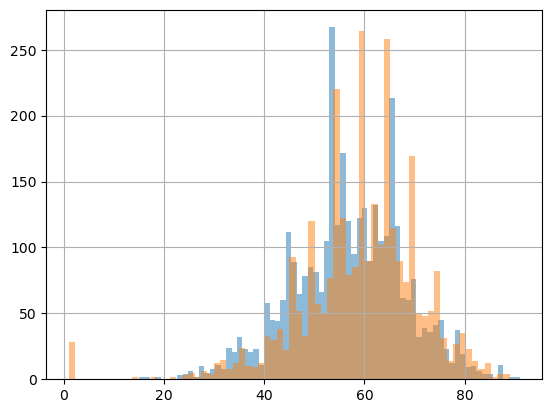

In [109]:
metadata[metadata['Patient Sex']=='Male']['Patient Age'].hist(alpha=0.5,bins=70)
metadata[metadata['Patient Sex']=='Female']['Patient Age'].hist(alpha=0.5,bins=70)

Wie sind die label über 'Patient Sex' verteilt?

In [110]:
metadata[metadata['Patient Sex']=='Male'][label_column].sum()/metadata[label_column].sum()

N    0.558782
D    0.557230
G    0.579345
C    0.417910
A    0.542320
H    0.625616
M    0.352941
O    0.503149
dtype: float64

In [111]:
metadata[metadata['Patient Sex']=='Female'][label_column].sum()/metadata[label_column].sum()

N    0.441218
D    0.442770
G    0.420655
C    0.582090
A    0.457680
H    0.374384
M    0.647059
O    0.496851
dtype: float64

In [112]:
metadata[label_column].sum()

N    2101
D    2123
G     397
C     402
A     319
H     203
M     306
O    1588
dtype: int64

Beim Training müssen die Verteilung der Label besonders berücksichtigen. Die Klassen *N, D, O* sind relativ gebalanced, während die anderen bis zu 10 mal unterrepräsentiert sind. *H* und *M* sind nicht gleichmäßig in beiden geschlechtern vertreten, aber der Bias ist hier nicht alzu stark. 

#### Do we have to worry about "data leakage", something that often comes from having many datapoints for the same patients ?

Wenn wir den Datensatzt unbereinigt nutzen und die Label zusammen mit filename nutzen würden, hätten wir einige label Doppelt mit relativ ähnlichen Augen. Da die doppelten Patienten IDs zwar von der selben Person aber immer von anderem Auge, ist dieses 'leakage' zwar vorhanden nicht gravierend. Selbst wenn die Bilder beinahe identische Merkmale aufweisen wären sie noch mindestens gespiegelt. Nicht jede ID ist zweimal vertreten.

Ein größeres Problem wären die bereits thematisierten unverlässlichen Label.

## Have a look at some of the images

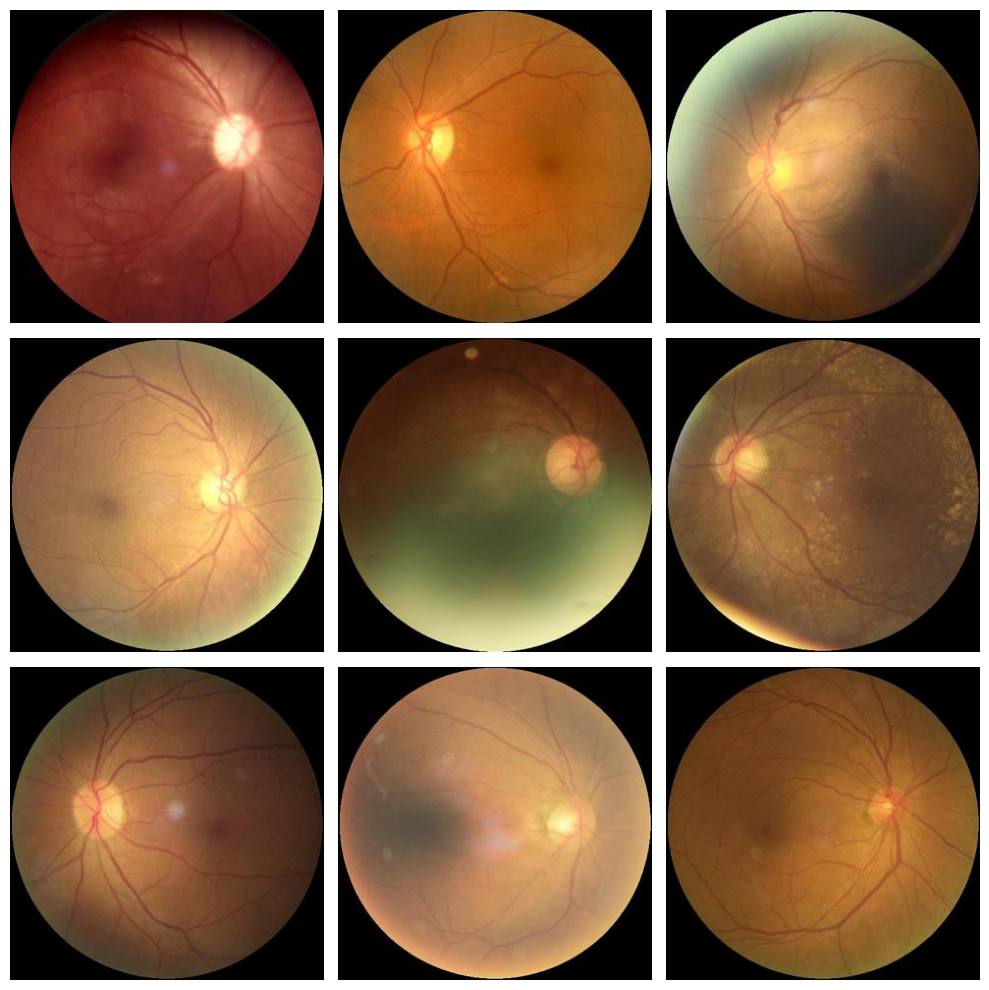

In [113]:
path_images = r"ocular_disease_recognition_small\preprocessed_images_small"

# Pick 9 random images
np.random.seed(2)
random_images = np.random.choice(metadata.filename, 9)

# Adjust the size of your images
plt.figure(figsize=(10,10))

# Iterate and plot random images
for i, filename in enumerate(random_images):
    plt.subplot(3, 3, i + 1)
    img = plt.imread(os.path.join(path_images, filename))
    plt.imshow(img)
    plt.axis('off')
    
# Adjust subplot parameters to give specified padding
plt.tight_layout()    

## 2. Prepare data for machine learning: 
- Separate data / labels
- Split into train ~70% / validation ~15% / test ~15%

In [114]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(metadata,
                                     test_size=0.2,
                                     random_state=0
                                    )
print(f"Training set size: {train_df.shape}")
print(f"Test set size: {test_df.shape}")

# second split
test_df, val_df = train_test_split(test_df,
                                    test_size=0.5,
                                    random_state=0
                                    )
print(f"Training set size: {train_df.shape}")
print(f"Validation set size: {val_df.shape}")
print(f"Test set size: {test_df.shape}")

Training set size: (5113, 19)
Test set size: (1279, 19)
Training set size: (5113, 19)
Validation set size: (640, 19)
Test set size: (639, 19)


## 3. Build an image generator pipeline
- Create a Pytroch `Dataset` child class `train_dataset` and a `validation_dataset` (feel free to adapt the `XRayDataset` from the pytorch_utils.py)
- Use the generator to recale the pixel values and to reshape the image to the desired format.
- Use the Pytorch `DataLoader` as a generator for the later training:
```python
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
```

Adaptiertes Dataset, mit automatischer Label Erkennung basierend auf dem ermittelten keyword_label_dict.

In [115]:
import os
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.io import read_image, ImageReadMode
from torchvision import transforms

class OcularDataset(Dataset):
    """
    A custom PyTorch Dataset class for chest ocular images.

    This class is designed to handle ocular image datasets, supporting both grayscale
    and RGB image modes. It allows for on-the-fly transformations of the images and labels,
    facilitating data augmentation and preprocessing steps.

    Parameters:
    - metadata (pd.DataFrame): DataFrame containing image metadata (e.g., filenames, labels).
    - img_dir (str): Directory path where images are stored.
    - classes (list): List of Label column names in `metadata` representing the label(s) for each image. Accepting each ['N', 'D' , 'G' ,'C', 'A', 'H', 'M', 'O']
    - img_mode (str, optional): The mode of the images, either "RGB" or "GRAY". Default is "RGB".
    - transform (callable, optional): A function/transform that takes in an image and returns a transformed version. E.g., data augmentation procedures.
    - target_transform (callable, optional): A function/transform that takes in the target and transforms it.

    Usage:
    dataset = XRayDataset(metadata=df, img_dir="/path/to/images", classes=['Normal', 'Pneumonia'], img_mode='RGB')
    """
    def __init__(
        self,
        metadata: pd.DataFrame,
        img_dir: str,
        classes: list,
        keyword_label_dict: dict,
        img_mode: str = "RGB",
        transform=None,
        target_transform=None,
    ):
        self.img_metadata = metadata
        self.img_dir = img_dir
        self.classes = classes
        if img_mode.lower() == "rgb":
            self.img_mode = ImageReadMode.RGB
        elif img_mode.lower() == "gray":
            self.img_mode = ImageReadMode.GRAY
        else:
            raise ValueError("Unknown image mode (img_mode), must be GRAY or RGB.")
        self.transform = transform
        self.target_transform = target_transform
        self.keyword_label_dict = keyword_label_dict

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.img_metadata)

    def __getitem__(self, idx):
        """Retrieves the image and its label at the specified index `idx`.

        Parameters:
        - idx (int): Index of the item to retrieve.

        Returns:
        - tuple: (image, label) where image is the transformed image tensor, and label is the corresponding label tensor.
        """
        # Construct the full path to the image file
        img_path = os.path.join(self.img_dir, self.img_metadata['filename'].iloc[idx])
 
        # Read the image file
        image = read_image(img_path, mode=self.img_mode)
        image = image.to(torch.float32)/255

        # Extract label for the current image
        if 'left' in self.img_metadata['filename'].iloc[idx]:
            diagnostic_keywords = self.img_metadata['Left-Diagnostic Keywords'].str.replace(r'/s', '', regex=True).replace(r'[,，]', ';', regex=True).iloc[idx]
        elif 'right' in self.img_metadata['filename'].iloc[idx]:
            diagnostic_keywords = self.img_metadata['Right-Diagnostic Keywords'].str.replace(r'/s', '', regex=True).replace(r'[,，]', ';', regex=True).iloc[idx]
            
        diagnostic_keywords = diagnostic_keywords.split(sep=';')
        label_set = set()

        for keyword in diagnostic_keywords:
            if keyword == 'lens dust':
                continue
            elif ('N' in self.classes) and (keyword == 'normal fundus'):
                label_set.add('N')
            else:
                label = self.keyword_label_dict.get(keyword)
                if label != None:
                    label = label[0]
                if label in self.classes:
                    label_set.add(label)

        
        label = torch.tensor([1 if cls in label_set else 0 for cls in self.classes], dtype=torch.float32)

        # Apply transformations to the image and label if any
        if self.transform:
            image = self.transform(image)
        if self.target_transform:
            label = self.target_transform(label)

        return image, label


## CNN Exercise 1: Build and train a CNN with 5 Convolutional layers (**binary classification**)
- Build a CNN with 5 Convolution + pooling layers for predicting one conditions ("D" --> Diabetes)
- Train with images of the size 320 x 320 (grayscale or RGB is up to you)
- Evaluate the model

CNN Modell mit Ähnlicher Architektur in der Vorlesung:

In [154]:
class CNNModel(nn.Module):
    """
    A simple 5‐layer convolutional network followed by two fully connected layers.
    Input: 3×320×320 RGB image or 1×320×320 grayscale image
    Output: num_classes logistic probabilities (sigmoid)

    Parameters:
    - mode (string): 'RGB' or 'grey' to determine the size of the input channels.
    """
    def __init__(self, num_classes: int, mode='RGB'):
        super().__init__()
        if mode == 'RGB': in_channels = 3
        if mode == 'grey': in_channels = 1

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=192, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(in_channels=192, out_channels=192, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        flattened_size = 192 * 10 * 10

        self.fc1 = nn.Linear(flattened_size, 64)
        self.fc2 = nn.Linear(64, num_classes)

        self.output_activation = nn.Sigmoid()

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = self.pool(x)

        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = F.relu(self.conv5(x))
        x = self.pool(x)

        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))

        x = self.output_activation(self.fc2(x))
        return x

___________________________________________________________________________________________________________________________

Training

In [155]:
transform = transforms.Compose([
    transforms.Resize((320, 320))
])

In [156]:
train_dataset = OcularDataset(train_df,'C:\E_Backup\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small', classes=['D'], transform= transform,keyword_label_dict=keyword_label_dict)
val_dataset = OcularDataset(val_df,'C:\E_Backup\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small', classes=['D'], transform= transform,keyword_label_dict=keyword_label_dict)

In [157]:
train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=50, shuffle=False)

In [158]:
model = CNNModel(1, 'RGB')

In [159]:
summary(model)

Layer (type:depth-idx)                   Param #
CNNModel                                 --
├─Conv2d: 1-1                            896
├─Conv2d: 1-2                            18,496
├─Conv2d: 1-3                            73,856
├─Conv2d: 1-4                            221,376
├─Conv2d: 1-5                            331,968
├─MaxPool2d: 1-6                         --
├─Linear: 1-7                            1,228,864
├─Linear: 1-8                            65
├─Sigmoid: 1-9                           --
Total params: 1,875,521
Trainable params: 1,875,521
Non-trainable params: 0

Da ich eine AMD Grafikarte habe, hab ich mich nach CUDA alternativen umgeschaut. Direct ML nutzt Direct X um die API für das Training von ML Modellen auf der Grafikarte zu ermöglichen. Nicht alle Operationen (z.b. manche Lossfunktionen sind unterstützt und müssen auf dem CPU berechnet werden):

In [160]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch_directml.device_count() > 0:
    device = torch_directml.device()
else:
    device = torch.device("cpu")

print(f"Benutztes Gerät: {device}")

Benutztes Gerät: privateuseone:0


Eine lr von 0,00001 bot hier ein lernverhalten, bei dem das CNN nicht direkt Overfittet. Das beste Modell wird immer wieder abgespeichert um nicht immer ein neues training starten zu müssen.

In [161]:
EPOCHS = 10
model = CNNModel(1, 'RGB').to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
loss_fn = nn.BCELoss()

print(f"Training will happen on {device}.")

best_vloss = np.inf


for epoch in range(EPOCHS):
    print(f"EPOCH {epoch + 1}")

    model.train(True)

    avg_loss = 0.

    for i, data in enumerate(tqdm(train_loader)):
        inputs, labels = data
        optimizer.zero_grad()
         
        outputs = model(inputs.to(device))
        loss = loss_fn(outputs, labels.to(device))
        
        loss.backward()

        optimizer.step()

        avg_loss += loss.item()

    avg_loss = avg_loss / len(train_loader)

    # validation 
    running_vloss = 0.0
    model.eval()

    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device))
            running_vloss += vloss

        # print(running_vloss/len(val_loader))

        avg_vloss = running_vloss / (i + 1)
        print(f"LOSS train {avg_loss:.3f} valid {avg_vloss:.3f}")

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f"1_model"
        torch.save(model.state_dict(), model_path)


Training will happen on privateuseone:0.
EPOCH 1


100%|██████████| 103/103 [00:29<00:00,  3.52it/s]


LOSS train 0.624 valid 0.581
EPOCH 2


100%|██████████| 103/103 [00:29<00:00,  3.53it/s]


LOSS train 0.590 valid 0.577
EPOCH 3


...

LOSS train 0.578 valid 0.571
EPOCH 9


100%|██████████| 103/103 [00:29<00:00,  3.50it/s]


LOSS train 0.578 valid 0.569
EPOCH 10


100%|██████████| 103/103 [00:28<00:00,  3.56it/s]


LOSS train 0.577 valid 0.572


Bemerkung zum Training: Am Anfang reduziert sich der Validation loss stetig. Nach der 5 Epoche beginnt das Overfitting

Code zum evaluieren der Klassifikationsleistung von Modellen:

In [ ]:
def eval_model(test_dataset, model, classes):
    labels_test = np.array([label for _,label in test_dataset])
    dataloader = DataLoader(test_dataset, batch_size=50, shuffle=False)
    prediction_proba_test, prediction_labels_test = predict(model, dataloader)

    print("label sum predicted: " , sum(prediction_labels_test))
    print("label sum correct: " , sum(labels_test))

    print("labels shape: ", labels_test.shape)
    print("predicted proba shape: ", prediction_proba_test.shape)
    print("predicted labels shape: ", prediction_labels_test.shape)

    if(len(classes)== 1):
        conf_matrix = confusion_matrix(labels_test, np.array(prediction_labels_test))
        plot_confusion_matrix(conf_matrix)
        print(classification_report(labels_test, prediction_labels_test,zero_division=0))
    else:
        print(classification_report(labels_test, prediction_labels_test,zero_division=0, target_names = classes))

    plot_roc_curves(labels_test, prediction_proba_test, classes, dpi= 90)

def predict(model, dataloader):
    model.eval()
    model.to(device)

    all_preds_proba = []
    all_preds_label = []

    with torch.no_grad(): 
        for batch in dataloader:
            inputs, _ = batch
            inputs = inputs.to(device)

            outputs = model(inputs) 

            all_preds_proba.append(outputs)

            preds_label = (outputs >= 0.5).long()
            all_preds_label.append(preds_label.cpu())

    return torch.cat(all_preds_proba).cpu(), torch.cat(all_preds_label).cpu()

def plot_confusion_matrix(confusion_matrix):
    """ Simple plot of a confusion matrix using Seaborn's heatmap."""
    plt.figure(figsize=(6, 4), dpi=100)
    sb.heatmap(confusion_matrix, annot=True, annot_kws={"size": 16},
                cmap="Purples",
                fmt="g")

    # Set labels and title
    plt.xlabel('Predicted', fontsize=16)
    plt.ylabel('Actual', fontsize=16)
    plt.title('Confusion Matrix', fontsize=20)

## Von pytorch_utils.py aus der Vorlesung
def plot_roc_curves(labels_val, predictions_val, classes, figsize=(8, 8), dpi=150):
    """
    Plot ROC curves for multi-class classification.
    
    Parameters:
    -----------
    labels_val : np.ndarray
        Ground truth binary labels with shape (n_samples, n_classes).
    predictions_val : np.ndarray
        Predicted probabilities with shape (n_samples, n_classes).
    classes : list of str
        List of class names corresponding to each column.
    figsize : tuple, optional
        Size of the figure (default is (8, 8)).
    dpi : int, optional
        Resolution of the figure (default is 150).
    """
    n_classes = len(classes)

    fpr, tpr, roc_auc = {}, {}, []

    # Compute ROC curve and AUC for each class
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(labels_val[:, i], predictions_val[:, i])
        roc_auc.append(auc(fpr[i], tpr[i]))

    # Sort classes by AUC descending
    sorted_by_auc = np.argsort(roc_auc)[::-1]
    color_map = plt.get_cmap("tab20b", n_classes)

    # Plot
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    for count, i in enumerate(sorted_by_auc):
        ax.plot(
            fpr[i], tpr[i],
            color=color_map.colors[count],
            lw=2,
            label=f"{classes[i]}, area = {roc_auc[i]:.2f}"
        )

    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('Receiver Operating Characteristic for Multi-Class Classification')
    ax.legend(loc="lower right", fontsize=10)
    plt.show()

laden des Testdatensatzes und models:

In [170]:
test_dataset = OcularDataset(test_df,'ocular_disease_recognition_small\preprocessed_images_small', classes=['D'], transform= transform,keyword_label_dict=keyword_label_dict)

In [171]:
model = CNNModel(1, 'RGB').to(device)
model.load_state_dict(torch.load(r"1_model"))

<All keys matched successfully>

label sum predicted:  tensor([0])
label sum correct:  [170.]
labels shape:  (639, 1)
predicted proba shape:  torch.Size([639, 1])
predicted labels shape:  torch.Size([639, 1])
              precision    recall  f1-score   support

         0.0       0.73      1.00      0.85       469
         1.0       0.00      0.00      0.00       170

    accuracy                           0.73       639
   macro avg       0.37      0.50      0.42       639
weighted avg       0.54      0.73      0.62       639



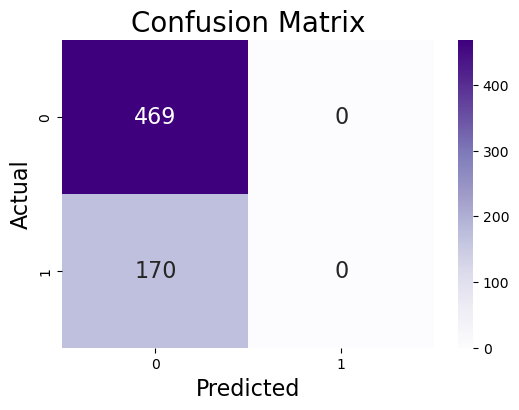

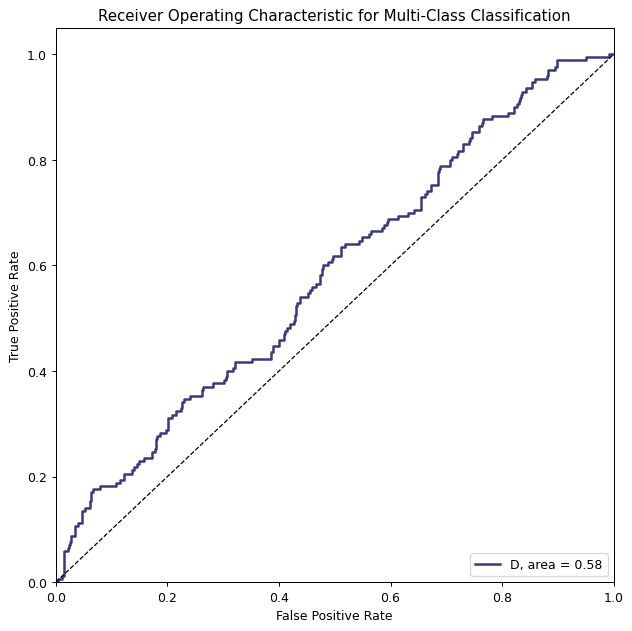

In [172]:
eval_model(test_dataset, model, classes=['D'])

Modell Eval: Das Modell hat nicht einmal die Positive klasse vorhergesagt. Mit der Methode hat es zwar 73% Accuracy, aber dieser Erfolg liegt dem Bias im Datensatz zu Grunde.

## CNN Exercise 2: Build and train a CNN with 5 Convolutional layers (**multi-label prediction**)
- Build a CNN with 5 Convolution + pooling layers for predicting all provided conditions
- Train with images of the size 320 x 320 (grayscale or RGB is up to you)
- Evaluate the model

In [128]:
label_column = ['N', 'D', 'G', 'C', 'A', 'H', 'M']

Neues erstellen der Datensätze, da die Ausgabe abhängig ist von den classes die vorhergesagt werden sollen:

In [129]:
train_dataset = OcularDataset(train_df,'C:\E_Backup\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small', classes=label_column, transform= transform,keyword_label_dict=keyword_label_dict)
val_dataset = OcularDataset(val_df,'C:\E_Backup\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small', classes=label_column, transform= transform,keyword_label_dict=keyword_label_dict)

train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=50, shuffle=False)

Eine lr von 0,0005 bot das beste lernverhalten.

In [130]:
EPOCHS = 20
model = CNNModel(7, 'RGB').to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.BCELoss()

print(f"Training will happen on {device}.")

best_vloss = np.inf


for epoch in range(EPOCHS):
    print(f"EPOCH {epoch + 1}")

    model.train(True)

    avg_loss = 0.

    for i, data in enumerate(tqdm(train_loader)):
        inputs, labels = data
        optimizer.zero_grad()
         
        outputs = model(inputs.to(device))
        loss = loss_fn(outputs, labels.to(device))

        loss.backward()

        optimizer.step()

        avg_loss += loss.item()

    avg_loss = avg_loss / len(train_loader)

    # validation 
    running_vloss = 0.0
    model.eval()

    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            voutputs = model(vinputs.to(device))
            vloss = loss_fn(voutputs, vlabels.to(device))
            running_vloss += vloss

        # print(running_vloss/len(val_loader))

        avg_vloss = running_vloss / (i + 1)
        print(f"LOSS train {avg_loss:.3f} valid {avg_vloss:.3f}")

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f"2_model"
        torch.save(model.state_dict(), model_path)


Training will happen on privateuseone:0.
EPOCH 1


100%|██████████| 103/103 [00:29<00:00,  3.45it/s]


LOSS train 0.328 valid 0.315
EPOCH 2


100%|██████████| 103/103 [00:30<00:00,  3.38it/s]


LOSS train 0.309 valid 0.308
EPOCH 3


...

LOSS train 0.253 valid 0.279
EPOCH 19


100%|██████████| 103/103 [00:27<00:00,  3.71it/s]


LOSS train 0.252 valid 0.280
EPOCH 20


100%|██████████| 103/103 [00:27<00:00,  3.75it/s]


LOSS train 0.246 valid 0.282


Bemerkung zum Training: Stetige verbesserung bis zur 13en Epoche, danach Overfittet das Modell.

In [173]:
test_dataset = OcularDataset(test_df,'ocular_disease_recognition_small\preprocessed_images_small', classes=label_column, transform= transform,keyword_label_dict=keyword_label_dict)

In [174]:
model = CNNModel(7, 'RGB').to(device)
model.load_state_dict(torch.load(r"2_model"))

<All keys matched successfully>

In [175]:
eval_model(test_dataset, model, classes=label_column)

label sum predicted:  tensor([239,  24,   2,  20,   0,   0,  21])
label sum correct:  [305. 170.  34.  26.  21.  18.  22.]
labels shape:  (639, 7)
predicted proba shape:  torch.Size([639, 7])
predicted labels shape:  torch.Size([639, 7])


TypeError: got an unexpected keyword argument 'class_name_dict'

Modell Eval: 

## CNN Exercise 3: Apply transfer Learning (multi-label prediction)
- Use transfer learning for predicting all provided conditions
- Adapt the image size accordingly using torchvision transforms
- You can pick any pre-trained model provided by pytorch (better avoid the biggest models)
- Evaluate the model

Moedell Weights importieren, sowie torchvision 

In [134]:
from torchvision.models import ResNet18_Weights
import torchvision

Resnet18 wird mit den default weights initialisiert. Die lr bot auch hier ein stabiles lernen ohne schnelles Overfitting

In [135]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch_directml.device_count() > 0:
    device = torch_directml.device()
else:
    device = torch.device("cpu")

print(f"Benutztes Gerät: {device}")

model_resnet = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)  
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 7)
model_resnet.to(device)

EPOCHS = 20

optimizer = torch.optim.Adam(model_resnet.parameters(), lr=1e-5)
loss_fn = nn.BCELoss()

print(f"Training will happen on {device}.")

best_vloss = np.inf


for epoch in range(EPOCHS):
    print(f"EPOCH {epoch + 1}")

    model_resnet.train(True)

    avg_loss = 0.

    for i, data in enumerate(tqdm(train_loader)):
        inputs, labels = data
        optimizer.zero_grad()
         
        outputs = nn.Sigmoid()(model_resnet(inputs.to(device)))

        loss = loss_fn(outputs, labels.to(device))

        loss.backward()

        optimizer.step()

        avg_loss += loss.item()

    avg_loss = avg_loss / len(train_loader)

    # validation 
    running_vloss = 0.0
    model_resnet.eval()

    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            voutputs = nn.Sigmoid()(model_resnet(vinputs.to(device)))
            vloss = loss_fn(voutputs, vlabels.to(device))
            running_vloss += vloss

        # print(running_vloss/len(val_loader))

        avg_vloss = running_vloss / (i + 1)
        print(f"LOSS train {avg_loss:.3f} valid {avg_vloss:.3f}")

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f"3_model_resnet"
        torch.save(model.state_dict(), model_path)

Benutztes Gerät: privateuseone:0
Training will happen on privateuseone:0.
EPOCH 1


100%|██████████| 103/103 [00:37<00:00,  2.72it/s]


LOSS train 0.684 valid 0.591
EPOCH 2


100%|██████████| 103/103 [00:37<00:00,  2.74it/s]


LOSS train 0.423 valid 0.382
EPOCH 3


...

LOSS train 0.069 valid 0.251
EPOCH 19


100%|██████████| 103/103 [00:40<00:00,  2.55it/s]


LOSS train 0.062 valid 0.252
EPOCH 20


100%|██████████| 103/103 [00:42<00:00,  2.42it/s]


LOSS train 0.057 valid 0.253


Bemerkung zum Training: *!!!!!!!!!!!!!!!!!!!!!*

In [136]:
model_resnet = torchvision.models.resnet18()  
model_resnet.fc = nn.Linear(model_resnet.fc.in_features, 7)
model_resnet.load_state_dict(torch.load(r"1_model_resnet_e4"))

<All keys matched successfully>

label sum predicted:  tensor([10,  4,  0,  0,  0,  0,  0])
label sum correct:  [305. 170.  34.  26.  21.  18.  22.]
labels shape:  (639, 7)
predicted proba shape:  torch.Size([639, 7])
predicted labels shape:  torch.Size([639, 7])
              precision    recall  f1-score   support

           0       1.00      0.03      0.06       305
           1       0.50      0.01      0.02       170
           2       0.00      0.00      0.00        34
           3       0.00      0.00      0.00        26
           4       0.00      0.00      0.00        21
           5       0.00      0.00      0.00        18
           6       0.00      0.00      0.00        22

   micro avg       0.86      0.02      0.04       596
   macro avg       0.21      0.01      0.01       596
weighted avg       0.65      0.02      0.04       596
 samples avg       0.02      0.02      0.02       596



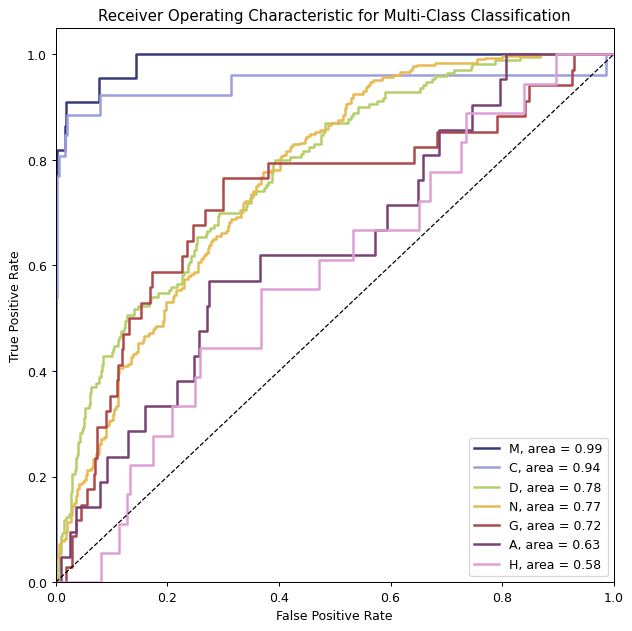

In [137]:
eval_model(test_dataset, model_resnet, classes=label_column)

Modell Eval: **!!!!!!!!!!!!!!!!!!!!!!!!**

## CNN Exercise 4: class weights
- Train the CNN from exercise 2 **or** 3 again using class weights (see for instance: https://saturncloud.io/blog/using-weights-in-crossentropyloss-and-bceloss-pytorch/).
- How does this affect the results? Is this better/similar/worse?

sklearn bietet utils an um die class weights zu berechnen:

In [138]:
from sklearn.utils.class_weight import compute_class_weight

Laden der labels vom Dataset zur Evaluierung der weights:

In [139]:
labels = np.array([label for _,label in train_dataset])

In [140]:
pd.DataFrame(labels).value_counts()

0    1    2    3    4    5    6  
1.0  0.0  0.0  0.0  0.0  0.0  0.0    2286
0.0  1.0  0.0  0.0  0.0  0.0  0.0    1281
     0.0  0.0  0.0  0.0  0.0  0.0     499
               1.0  0.0  0.0  0.0     228
          1.0  0.0  0.0  0.0  0.0     196
          0.0  0.0  0.0  0.0  1.0     195
                    1.0  0.0  0.0     193
                    0.0  1.0  0.0      97
     1.0  0.0  0.0  0.0  1.0  0.0      47
          1.0  0.0  0.0  0.0  0.0      24
          0.0  0.0  1.0  0.0  0.0      16
     0.0  1.0  0.0  1.0  0.0  0.0      11
     1.0  0.0  1.0  0.0  0.0  0.0      10
     0.0  1.0  0.0  0.0  1.0  0.0       8
     1.0  0.0  0.0  0.0  0.0  1.0       8
     0.0  1.0  0.0  0.0  0.0  1.0       6
          0.0  0.0  1.0  1.0  0.0       4
               1.0  0.0  1.0  0.0       2
               0.0  1.0  0.0  1.0       1
          1.0  1.0  0.0  0.0  0.0       1
Name: count, dtype: int64

Weightsberechnung:

In [141]:
weights = []
for i in range(labels.shape[1]):
    class_weight = compute_class_weight(class_weight='balanced', classes=np.array([0,1]), y=labels[:, i])
    weights.append(class_weight[1])  

class_weights = torch.tensor(weights, dtype=torch.float32)

print(class_weights)

tensor([ 1.1183,  1.8445, 10.3923, 10.6079, 11.3622, 16.1804, 12.1738])


In [142]:
print('Class weights:')
for i, label_name in enumerate(label_column):
    print(label_name, ":", class_weights[i].item().__round__(2))

Class weights:
N : 1.12
D : 1.84
G : 10.39
C : 10.61
A : 11.36
H : 16.18
M : 12.17


In [143]:
model_resnet_e4 = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)  
model_resnet_e4.fc = nn.Linear(model_resnet_e4.fc.in_features, 7)
model_resnet_e4.to(device)

EPOCHS = 20

optimizer = torch.optim.Adam(model_resnet_e4.parameters(), lr=1e-5)
loss_fn = nn.BCEWithLogitsLoss(pos_weight=class_weights.to(device))

print(f"Training will happen on {device}.")

best_vloss = np.inf


for epoch in range(EPOCHS):
    print(f"EPOCH {epoch + 1}")

    model_resnet_e4.train(True)

    avg_loss = 0.

    for i, data in enumerate(tqdm(train_loader)):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device) 
        
        optimizer.zero_grad()
         
        outputs = model_resnet_e4(inputs)
        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        avg_loss += loss.item()

    avg_loss = avg_loss / len(train_loader)

    # validation 
    running_vloss = 0.0
    model_resnet_e4.eval()

    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            voutputs = model_resnet_e4(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

        # print(running_vloss/len(val_loader))

        avg_vloss = running_vloss / (i + 1)
        print(f"LOSS train {avg_loss:.3f} valid {avg_vloss:.3f}")

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f"4_model_resnet_e4"
        torch.save(model_resnet_e4.state_dict(), model_path)

Training will happen on privateuseone:0.
EPOCH 1


100%|██████████| 103/103 [00:38<00:00,  2.65it/s]


LOSS train 0.912 valid 0.817
EPOCH 2


100%|██████████| 103/103 [00:38<00:00,  2.65it/s]


LOSS train 0.725 valid 0.693
EPOCH 3


...

LOSS train 0.138 valid 0.587
EPOCH 19


100%|██████████| 103/103 [00:38<00:00,  2.65it/s]


LOSS train 0.123 valid 0.597
EPOCH 20


100%|██████████| 103/103 [00:41<00:00,  2.47it/s]


LOSS train 0.108 valid 0.600


Bemerkung zum Training: *!!!!!!!!!!!!!!!!!!!!!*

In [144]:
model_resnet_e4 = torchvision.models.resnet18()  
model_resnet_e4.fc = nn.Linear(model_resnet_e4.fc.in_features, 7)
model_resnet_e4.load_state_dict(torch.load(r"4_model_resnet_e4"))

<All keys matched successfully>

label sum predicted:  tensor([188,  88,  38,  37,  19,  18,  26])
label sum correct:  [305. 170.  34.  26.  21.  18.  22.]
labels shape:  (639, 7)
predicted proba shape:  torch.Size([639, 7])
predicted labels shape:  torch.Size([639, 7])
              precision    recall  f1-score   support

           0       0.77      0.47      0.58       305
           1       0.61      0.32      0.42       170
           2       0.42      0.47      0.44        34
           3       0.62      0.88      0.73        26
           4       0.42      0.38      0.40        21
           5       0.28      0.28      0.28        18
           6       0.77      0.91      0.83        22

   micro avg       0.65      0.45      0.53       596
   macro avg       0.56      0.53      0.53       596
weighted avg       0.67      0.45      0.53       596
 samples avg       0.40      0.42      0.41       596



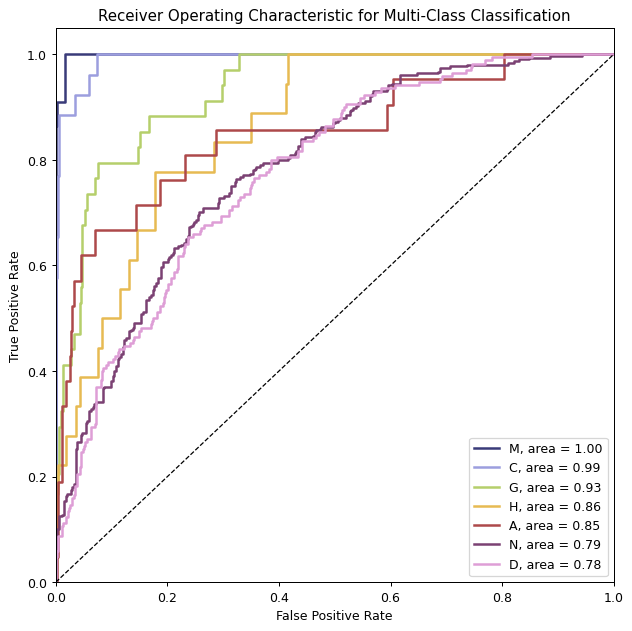

In [145]:
eval_model(test_dataset, model_resnet_e4, classes=label_column)

Modell Eval: **!!!!!!!!!!!!!!!!!!!!!!!!**

## CNN Exercise 5: Data augmentation
- Again, train the CNN from exercise 2 **or** 3. But now, add a few suitable (randomized) image transformations to increase the variation of the training data. This can be done via the torchvision transforms, see [documentation](https://docs.pytorch.org/vision/stable/transforms.html).
- How does this affect the results? Is this better/similar/worse?

In [146]:
from torchvision.transforms import v2

### Welche Augmentierungsmethoden sind Valide?

Leichte Rotationen und Unterschiede in der Helligkeit oder im Kontrast, sind relativ Realitätsnah. Die dadurch verursachten Unterschiede könnten auch auf natürlich Art bei den selben Patienten vorkommen, wenn die Fotos z.B. mit einem Anderen gerät aufgenommen werden. Noise und Schärfe könnte auch von Kamera zu Kamera leicht variieren, wobei man hier nicht zu destruktiv sein darf. Auch Skalierung und Translation können bei leichter Anwendung zu einem Robusteren Modell führen und zerstören keine Merkmale die zur Diagnose notwendig, da die Ränder bei uns wenig Information enthalten. 

In [147]:
augment_transforms = v2.Compose([
    v2.Resize((320, 320)),
    v2.ColorJitter(
        brightness=0.2,     
        contrast=0.2,     
        hue=0.01            
    ),
    v2.RandomAffine(degrees=10, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    v2.RandomApply([
        v2.GaussianBlur(kernel_size=3, sigma=(0.1, 0.3))
    ], p=0.2),
    v2.RandomApply([
        v2.GaussianNoise(mean=0.0, sigma=(0.05))
    ], p=0.2),
])

In [148]:
train_dataset = OcularDataset(train_df,'C:\E_Backup\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small', classes=label_column, transform= augment_transforms,keyword_label_dict=keyword_label_dict)
# Ohne Augmentierung!:
val_dataset = OcularDataset(val_df,'C:\E_Backup\Dokumente\MMI\Datascience\DataScience\is\ocular_disease_recognition_small\preprocessed_images_small', classes=label_column, transform= transform,keyword_label_dict=keyword_label_dict)

Visuelle überprüfung der Sinnhaftigkeit der Augmentierung:

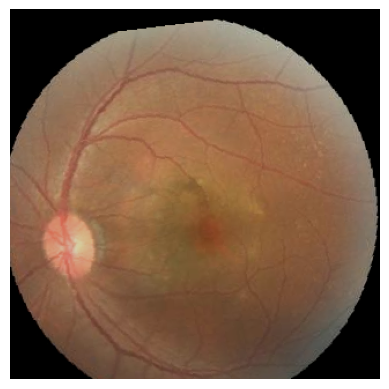

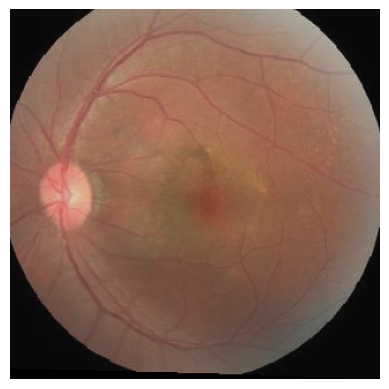

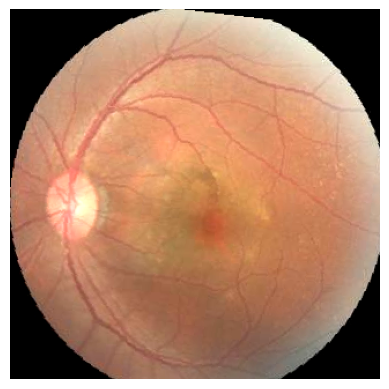

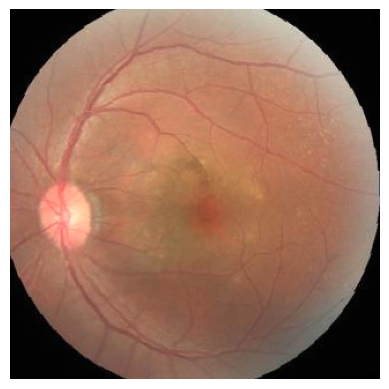

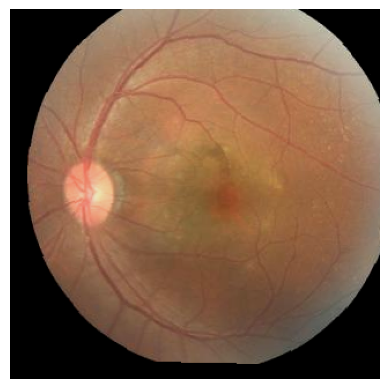

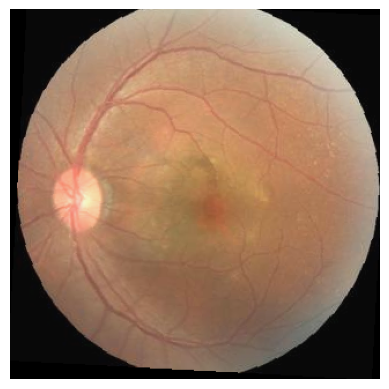

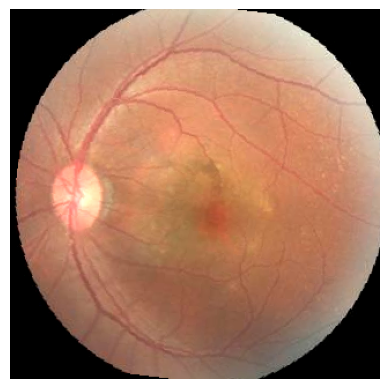

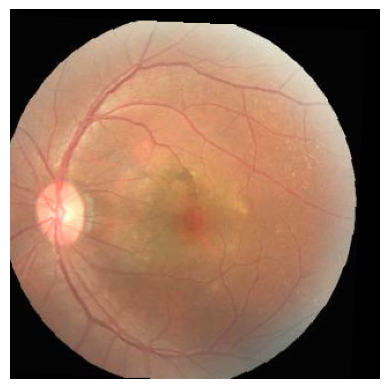

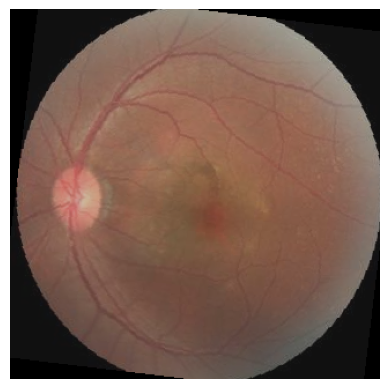

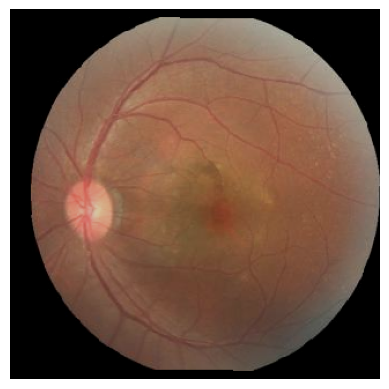

In [149]:
for i in range(10):
    img = train_dataset[0][0].permute(1, 2, 0).numpy()

    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [150]:
train_loader = DataLoader(train_dataset, batch_size=50, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=50, shuffle=False)

In [151]:
model_resnet_e5 = torchvision.models.resnet18(weights=ResNet18_Weights.DEFAULT)  
model_resnet_e5.fc = nn.Linear(model_resnet_e5.fc.in_features, 7)
model_resnet_e5.to(device)

EPOCHS = 20

optimizer = torch.optim.Adam(model_resnet_e5.parameters(), lr=5e-5)
loss_fn = nn.BCEWithLogitsLoss()

print(f"Training will happen on {device}.")

best_vloss = np.inf


for epoch in range(EPOCHS):
    print(f"EPOCH {epoch + 1}")

    model_resnet_e5.train(True)

    avg_loss = 0.

    for i, data in enumerate(tqdm(train_loader)):
        inputs, labels = data

        inputs = inputs.to(device)
        labels = labels.to(device) 
        
        optimizer.zero_grad()
         
        outputs = model_resnet_e5(inputs)
        loss = loss_fn(outputs, labels)

        loss.backward()

        optimizer.step()

        avg_loss += loss.item()

    avg_loss = avg_loss / len(train_loader)

    # validation 
    running_vloss = 0.0
    model_resnet_e5.eval()

    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            vinputs = vinputs.to(device)
            vlabels = vlabels.to(device)
            voutputs = model_resnet_e5(vinputs)
            vloss = loss_fn(voutputs, vlabels)
            running_vloss += vloss

        # print(running_vloss/len(val_loader))

        avg_vloss = running_vloss / (i + 1)
        print(f"LOSS train {avg_loss:.3f} valid {avg_vloss:.3f}")

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f"5_model_resnet_e5"
        torch.save(model_resnet_e5.state_dict(), model_path)

Training will happen on privateuseone:0.
EPOCH 1


100%|██████████| 103/103 [01:01<00:00,  1.68it/s]


LOSS train 0.395 valid 0.270
EPOCH 2


100%|██████████| 103/103 [01:01<00:00,  1.66it/s]


LOSS train 0.248 valid 0.237
EPOCH 3


...

LOSS train 0.054 valid 0.289
EPOCH 19


100%|██████████| 103/103 [01:01<00:00,  1.68it/s]


LOSS train 0.052 valid 0.281
EPOCH 20


100%|██████████| 103/103 [01:00<00:00,  1.70it/s]


LOSS train 0.045 valid 0.302


Bemerkung zum Training: **!!!!!!!!!!!!!!!!!!!!!!!!**

In [152]:
model_resnet_e5 = torchvision.models.resnet18()  
model_resnet_e5.fc = nn.Linear(model_resnet_e4.fc.in_features, 7)
model_resnet_e5.load_state_dict(torch.load(r"5_model_resnet_e5"))

<All keys matched successfully>

label sum predicted:  tensor([281,  64,   5,  22,  12,   0,  21])
label sum correct:  [305. 170.  34.  26.  21.  18.  22.]
labels shape:  (639, 7)
predicted proba shape:  torch.Size([639, 7])
predicted labels shape:  torch.Size([639, 7])
              precision    recall  f1-score   support

           0       0.72      0.67      0.69       305
           1       0.83      0.31      0.45       170
           2       0.80      0.12      0.21        34
           3       0.95      0.81      0.88        26
           4       0.58      0.33      0.42        21
           5       0.00      0.00      0.00        18
           6       0.95      0.91      0.93        22

   micro avg       0.76      0.52      0.62       596
   macro avg       0.69      0.45      0.51       596
weighted avg       0.75      0.52      0.58       596
 samples avg       0.48      0.48      0.48       596



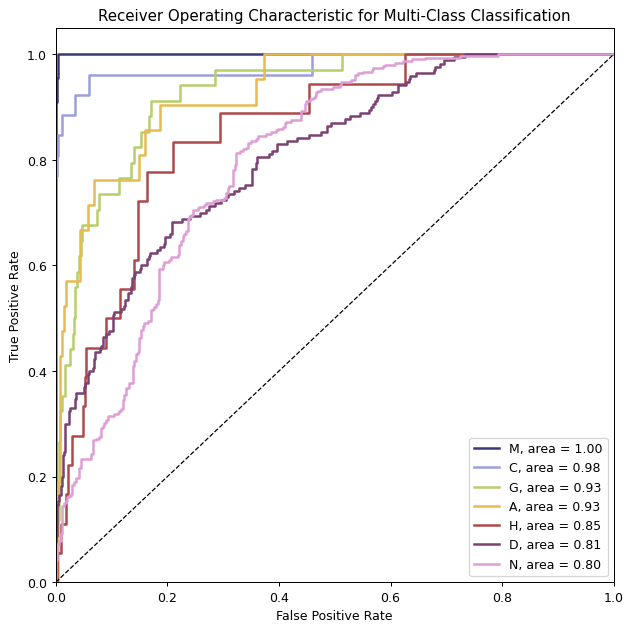

In [153]:
eval_model(test_dataset, model_resnet_e5, classes=label_column)

- How does this affect the results? Is this better/similar/worse?

Modell Eval: **!!!!!!!!!!!!!!!!!!!!!!!!**